In [13]:
from typing import TypedDict, List
from langgraph.graph import StateGraph

In [14]:
class AgentState(TypedDict):
    values: List[int]
    name: str
    result: str

In [ ]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)
    state['result'] = f'Hi there {state['name']}! Your sum = {sum(state['values'])}'
    print(state)
    return state

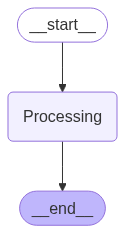

In [ ]:
graph = StateGraph(AgentState)
graph.add_node('Processing', process_values)
graph.set_entry_point('Processing')
graph.set_finish_point('Processing')
graph.compile()

### NOTE - THIS WORKS WITHOUT DEFININING state['result'] in the invoke function because in our node (process_values), we do not use it in any calculations, rather update it. 
### So if you want to use it somewhere then like the first part answer = , you need to define 'result': '' as something like this, else it is taken as None and then cannot be used in the node calculations thereby throwing an error

In [ ]:
app = graph.compile()
answer = app.invoke({'name':'Jayesh','result':'','values':[10,20,20,30]})
print()
answer2 = app.invoke({'name':'Jayesh','values':[10,20,20,30]})
print()

{'values': [10, 20, 20, 30], 'name': 'Jayesh', 'result': ''}
{'values': [10, 20, 20, 30], 'name': 'Jayesh', 'result': 'Hi there Jayesh! Your sum = 80'}

{'values': [10, 20, 20, 30], 'name': 'Jayesh'}
{'values': [10, 20, 20, 30], 'name': 'Jayesh', 'result': 'Hi there Jayesh! Your sum = 80'}


In [ ]:
answer3 = app.invoke({'name':'John','values':[50,80,5,10]})
print()
answer4 = app.invoke({'name':'Lia','values':[736,27,81]})
print()

In [ ]:
answer['result']
print(answer)

{'values': [10, 20, 20, 30], 'name': 'Jayesh', 'result': 'Hi there Jayesh! Your sum = 80'}
